In [1]:
## Load all necessary libraries

import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cf
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas
from matplotlib.ticker import AutoMinorLocator
import os
import scipy
from netCDF4 import Dataset as netcdf_dataset
import matplotlib
matplotlib.matplotlib_fname()
print(plt.style.available)
matplotlib.rcParams['font.sans-serif'] = 'Arial'

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
## Load all the climate model data (every simulation), pre-processed by ESMValTool

# This is how to load multiple files in alphabetical order
# Full set of directory lists:
CMIP5_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf all/baseline/'
CMIP5_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf all/endcentury/'
CMIP6_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf all/baseline/'
CMIP6_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf all/endcentury/'

# Initialise count and empty arrays for data
#P = np.empty(shape=(12,42,38,len(os.listdir(CMIP6_base_directory))+len(os.listdir(CMIP5_base_directory)),3))
P = np.empty(shape=(12,44,41,94+92,2))
count = 0

for dirpath, dirnames, filenames in os.walk(CMIP6_base_directory):
    dirnames.sort()
    names = sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
                               
            filenamelong = CMIP6_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,0] = P1[:,53:53+44,11:11+41] 
            count = count + 1

for dirpath, dirnames, filenames in os.walk(CMIP5_base_directory):
    dirnames.sort()
    names = names+sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP5_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,0] = P1[:,53:53+44,11:11+41] 
            count = count + 1

count = 0

            
for dirpath, dirnames, filenames in os.walk(CMIP6_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP6_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,1] = P1[:,53:53+44,11:11+41] 
            count = count + 1

for dirpath, dirnames, filenames in os.walk(CMIP5_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP5_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P[:,:,:,count,1] = P1[:,53:53+44,11:11+41] 
            count = count + 1



In [3]:
## Load some of the climate model data (one ripf member for each model), pre-processed by ESMValTool

# This is how to load multiple files in alphabetical order
# Full set of directory lists:
CMIP5_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf/baseline/'
CMIP5_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP5_30yr/netcdf/endcentury/'
CMIP6_base_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf/baseline/'
CMIP6_endc_directory = '/Users/ak0920/Data/ESMValTool/output/CMIP6_30yr/netcdf/endcentury/'

# Initialise count and empty arrays for data
#P = np.empty(shape=(12,42,38,len(os.listdir(CMIP6_base_directory))+len(os.listdir(CMIP5_base_directory)),3))
P2 = np.empty(shape=(12,44,41,44+39,2))
count = 0

for dirpath, dirnames, filenames in os.walk(CMIP6_base_directory):
    dirnames.sort()
    names2 = sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
                               
            filenamelong = CMIP6_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P2[:,:,:,count,0] = P1[:,53:53+44,11:11+41] 
            count = count + 1

for dirpath, dirnames, filenames in os.walk(CMIP5_base_directory):
    dirnames.sort()
    names2 = names2+sorted(filenames)
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP5_base_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P2[:,:,:,count,0] = P1[:,53:53+44,11:11+41] 
            count = count + 1

count = 0

            
for dirpath, dirnames, filenames in os.walk(CMIP6_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP6_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P2[:,:,:,count,1] = P1[:,53:53+44,11:11+41] 
            count = count + 1

for dirpath, dirnames, filenames in os.walk(CMIP5_endc_directory):
    dirnames.sort()
    for filename in sorted(filenames):
        if filename.endswith('.nc'):
            filenamelong = CMIP5_endc_directory+filename
            #print(filenamelong)
            thismod_ds = xr.open_dataset(filenamelong)
            P1 = thismod_ds["pr"] * 86400
            P2[:,:,:,count,1] = P1[:,53:53+44,11:11+41] 
            count = count + 1



In [4]:
## Generate date information

import datetime
from datetime import date
startt = date.fromisoformat('1980-01-01')
endt2 = date.fromisoformat('1981-01-01')

lats = thismod_ds.variables['lat'][53:53+44]
lons = thismod_ds.variables['lon'][11:11+41]
dates = pd.date_range(startt,endt2-datetime.timedelta(days=1),freq='m')


In [5]:
## Load file that defines if models are members of CORDEX or ISIMIP 
cordexisimip = pd.read_csv('CORDEX_ISIMIP.csv', sep=',',header = None)
ids2 = np.array(cordexisimip.loc[:,2:6])


In [6]:
## Create subsets for plotting

## Pull out specific ensemble members from full list of models
# Select CMIP6
matching6 = [s for s in names if "CMIP6" in s]
ids6 = [0]

for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP6" in s1:
        ids6.append(s)


# Select CMIP5
matching5 = [s for s in names if "CMIP5" in s]
ids5a = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP5" in s1:
        ids5a.append(s)

ids5 = ids5a[1:len(ids5a)]

# Select CSIRO
matchingCSIRO = [s for s in names if "CMIP5_CSIRO-Mk3-6-0_Amon_historical-rcp85" in s]
idsCSIROa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP5_CSIRO-Mk3-6-0_Amon_historical-rcp85" in s1:
        idsCSIROa.append(s)

idsCSIRO = idsCSIROa[1:len(idsCSIROa)]


# Select EC-EARTH
matchingECE = [s for s in names if "CMIP5_EC-EARTH_Amon_historical-rcp85" in s]
idsECEa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP5_EC-EARTH_Amon_historical-rcp85" in s1:
        idsECEa.append(s)

idsECE = idsECEa[1:len(idsECEa)]


# Select MIROC
matchingMIROC = [s for s in names if "CMIP6_MIROC6_Amon_historical-ssp585" in s]
idsMIROCa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP6_MIROC6_Amon_historical-ssp585" in s1:
        idsMIROCa.append(s)

idsMIROC = idsMIROCa[1:len(idsMIROCa)]


# Select CCSM4
matchingCCSM = [s for s in names if "CMIP5_CCSM4_Amon_historical-rcp85" in s]
idsCCSMa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP5_CCSM4_Amon_historical-rcp85" in s1:
        idsCCSMa.append(s)

idsCCSM = idsCCSMa[1:len(idsCCSMa)]


# Select CanESM
matchingCanESM = [s for s in names if "CMIP6_CanESM5_Amon_historical-ssp585" in s]
idsCanESMa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP6_CanESM5_Amon_historical-ssp585" in s1:
        idsCanESMa.append(s)

idsCanESM = idsCanESMa[1:len(idsCanESMa)]


# Select HadGEM3-GC31
matchingHadGEM = [s for s in names if "CMIP6_HadGEM3-GC31" in s]
idsHadGEMa = [0]
for s in range(1,len(names)):
    s1 = names[s]
    if "CMIP6_HadGEM3-GC31" in s1:
        idsHadGEMa.append(s)

idsHadGEM = idsHadGEMa[1:len(idsHadGEMa)]


# Select CORDEX
idsCORDEXa= [0]

for s in range(1,len(names)):
    if ids2[s,0]==1:
        idsCORDEXa.append(s)
idsCORDEX = idsCORDEXa[1:len(idsCORDEXa)]

# Select CORE
idsCORDEXa= [0]

for s in range(1,len(names)):
    if ids2[s,1]==1:
        idsCORDEXa.append(s)
idsCORE = idsCORDEXa[1:len(idsCORDEXa)]

# Select ISIMIP2b
idsCORDEXa= [0]

for s in range(1,len(names)):
    if ids2[s,2]==1:
        idsCORDEXa.append(s)
idsISIMIP2b = idsCORDEXa[1:len(idsCORDEXa)]

# Select ISIMIP3b primary only
idsCORDEXa= [0]

for s in range(1,len(names)):
    if ids2[s,3]==1:
        idsCORDEXa.append(s)
idsISIMIP3b = idsCORDEXa[1:len(idsCORDEXa)]

# Select ISIMIP3b all
idsCORDEXa= [0]

for s in range(1,len(names)):
    if ids2[s,3]==1:
        idsCORDEXa.append(s)
    elif ids2[s,4]==1:
        idsCORDEXa.append(s)
idsISIMIP3ball = idsCORDEXa[1:len(idsCORDEXa)]


In [7]:
## Load UKCP18
P_UKCP18 = np.empty([15, 12, 44, 40, 4]) # Empty array to fill – slightly different size but don't think this is an issue
UKCP18_ds = xr.open_dataset('/Users/ak0920/Data/UKCP18/Global/RCP8.5/UKCP18_regridded.nc')

P_UKCP18[:,:,:,:,0] = UKCP18_ds["P_past"]
P_UKCP18[:,:,:,:,1] = UKCP18_ds["P_near"]
P_UKCP18[:,:,:,:,2] = UKCP18_ds["P_midc"]
P_UKCP18[:,:,:,:,3] = UKCP18_ds["P_endc"]

lats_UKCP18 = UKCP18_ds.variables['latitude']
lons_UKCP18 = UKCP18_ds.variables['longitude']

UKCP18_change = P_UKCP18[:,:,:,:,3] - P_UKCP18[:,:,:,:,0]

# NOTE: Months in UKCP18 start at December, not January
# Calculate mean and SD
UKCP18_DJF = np.mean(P_UKCP18[:,[0,1,2],:,:], axis=1)
UKCP18_MAM = np.mean(P_UKCP18[:,[3,4,5],:,:], axis=1)
UKCP18_JJA = np.mean(P_UKCP18[:,[6,7,8],:,:], axis=1)
UKCP18_SON = np.mean(P_UKCP18[:,[9,10,11],:,:], axis=1)

# Calculate change mean and SD
UKCP18_DJF2 = np.mean(UKCP18_change[:,[0,1,2],:,:], axis=1)
UKCP18_MAM2 = np.mean(UKCP18_change[:,[3,4,5],:,:], axis=1)
UKCP18_JJA2 = np.mean(UKCP18_change[:,[6,7,8],:,:], axis=1)
UKCP18_SON2 = np.mean(UKCP18_change[:,[9,10,11],:,:], axis=1)

# Adjust the dimension order to match CMIP
P_UKCP18_2 = np.transpose(UKCP18_DJF[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_2[:,:,:,1] = np.transpose(UKCP18_DJF2[:,:,:], (1,2,0))
P_UKCP18_2a = np.transpose(UKCP18_MAM[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_2a[:,:,:,1] = np.transpose(UKCP18_MAM2[:,:,:], (1,2,0))
P_UKCP18_2b = np.transpose(UKCP18_JJA[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_2b[:,:,:,1] = np.transpose(UKCP18_JJA2[:,:,:], (1,2,0))
P_UKCP18_2c = np.transpose(UKCP18_SON[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_2c[:,:,:,1] = np.transpose(UKCP18_SON2[:,:,:], (1,2,0))
P_UKCP18_2.shape

# Take single months
UKCP18_D = np.squeeze(P_UKCP18[:,[0],:,:])
UKCP18_J = np.squeeze(P_UKCP18[:,[1],:,:])
UKCP18_F = np.squeeze(P_UKCP18[:,[2],:,:])
UKCP18_M = np.squeeze(P_UKCP18[:,[3],:,:])
UKCP18_A = np.squeeze(P_UKCP18[:,[4],:,:])
UKCP18_O = np.squeeze(P_UKCP18[:,[10],:,:])
UKCP18_N = np.squeeze(P_UKCP18[:,[11],:,:])

UKCP18_D2 = np.squeeze(UKCP18_change[:,[0],:,:])
UKCP18_J2 = np.squeeze(UKCP18_change[:,[1],:,:])
UKCP18_F2 = np.squeeze(UKCP18_change[:,[2],:,:])
UKCP18_M2 = np.squeeze(UKCP18_change[:,[3],:,:])
UKCP18_A2 = np.squeeze(UKCP18_change[:,[4],:,:])
UKCP18_O2 = np.squeeze(UKCP18_change[:,[10],:,:])
UKCP18_N2 = np.squeeze(UKCP18_change[:,[11],:,:])

# Adjust the dimension order to match CMIP
P_UKCP18_D = np.transpose(UKCP18_D[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_D[:,:,:,1] = np.transpose(UKCP18_D2[:,:,:], (1,2,0))
P_UKCP18_J = np.transpose(UKCP18_J[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_J[:,:,:,1] = np.transpose(UKCP18_J2[:,:,:], (1,2,0))
P_UKCP18_F = np.transpose(UKCP18_F[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_F[:,:,:,1] = np.transpose(UKCP18_F2[:,:,:], (1,2,0))
P_UKCP18_M = np.transpose(UKCP18_M[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_M[:,:,:,1] = np.transpose(UKCP18_M2[:,:,:], (1,2,0))
P_UKCP18_A = np.transpose(UKCP18_A[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_A[:,:,:,1] = np.transpose(UKCP18_A2[:,:,:], (1,2,0))
P_UKCP18_O = np.transpose(UKCP18_O[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_O[:,:,:,1] = np.transpose(UKCP18_O2[:,:,:], (1,2,0))
P_UKCP18_N = np.transpose(UKCP18_N[:,:,:,[0,3]], (1,2,0,3))
P_UKCP18_N[:,:,:,1] = np.transpose(UKCP18_N2[:,:,:], (1,2,0))


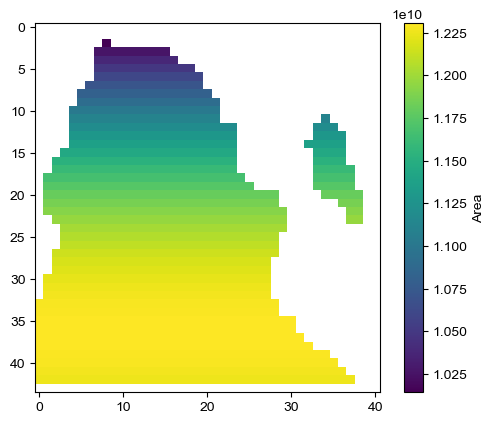

In [8]:
## Create Land-Sea Mask
# This is quite long, but it is quick and ensures a consistent LSM with the obs analysis
# Load observations
obs_ds = xr.open_dataset('/Users/ak0920/Data/Precipitation/Obs_regridded_long2.nc')
P_obs = obs_ds["P"]
lats_obs = obs_ds.variables['latitude']
lons_obs = obs_ds.variables['longitude']

# Convert data to numpy array
P_obs_arr = np.array(P_obs)

# To avoid mismatches in LSM relative to obs datasets, calculate LSM based on where obs are available
LSM1 = np.sum(np.isnan(P_obs_arr[:,1344,:,:,]),axis=0)
LSM2 = LSM1>0
LSM = np.abs(LSM2*1-1)

# Make ocean points NaN
mask_land = np.ones(LSM.shape)
for i in range(0,44):
    for j in range(0,41):        
        if LSM[i,j]==0:
            mask_land[i,j] = np.nan
            
# Calculate the global lat-long area per 1° grid cell
# Assuming the earth is a perfect sphere
def gridsize(lat1):
   #https://en.wikipedia.org/wiki/Haversine_formula
   #https://stackoverflow.com/questions/639695/how-to-convert-latitude-or-longitude-to-meters/11172685#11172685
   lon1=200
   import math
   lat2=lat1
   lon2=lon1+1

   R = 6378.137 # // Radius of earth in km
   dLat = lat2 * np.pi / 180 - lat1 * np.pi / 180
   dLon = lon2 * np.pi / 180 - lon1 * np.pi / 180
   a = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(lat1 * np.pi / 180) * np.cos(lat2 * np.pi / 180) * np.sin(dLon/2) * np.sin(dLon/2)
   c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
   d = R * c
   return d * 1000 #; // meters

boxlo,boxla=np.array(np.meshgrid(np.arange(-179.5,180.5,1),np.arange(-89.5,90.5,1)))
sizes=np.ones(boxlo.shape)
grid=gridsize(boxla)
grid_nc=xr.DataArray(grid,coords={'lat':boxla[:,1],'lon':boxlo[1,:]},dims=['lat','lon'])
lat_size=110567 #in m
grid_nc['m2']=grid_nc*lat_size
grid_nc=grid_nc['m2']

# Find ID of longitudes of global area grid for subset region where obs are available
lon_ids = np.arange(0,360,1)
which_id = boxlo[0,:] == np.array(lons_obs[0])
lon_id1 = lon_ids[which_id].item()
which_id = boxlo[0,:] == np.array(lons_obs[-1])
lon_id2 = lon_ids[which_id].item()+1
subsetlo = boxlo[0,lon_id1:lon_id2]

## Find ID of latitudes of global area grid for subset region
lat_ids = np.arange(0,180,1)
which_id = boxla[:,0] == np.array(lats_obs[0])
lat_id1 = lat_ids[which_id].item()
which_id = boxla[:,0] == np.array(lats_obs[-1])
lat_id2 = lat_ids[which_id].item()+1
subsetla = boxla[lat_id1:lat_id2,0]

## Create area-weighted LSM
LSM_area = grid_nc[lat_id1:lat_id2,lon_id1:lon_id2]*mask_land

# Create plot to check
plt.imshow(LSM_area)
cbar = plt.colorbar(label="Area")
plt.show()

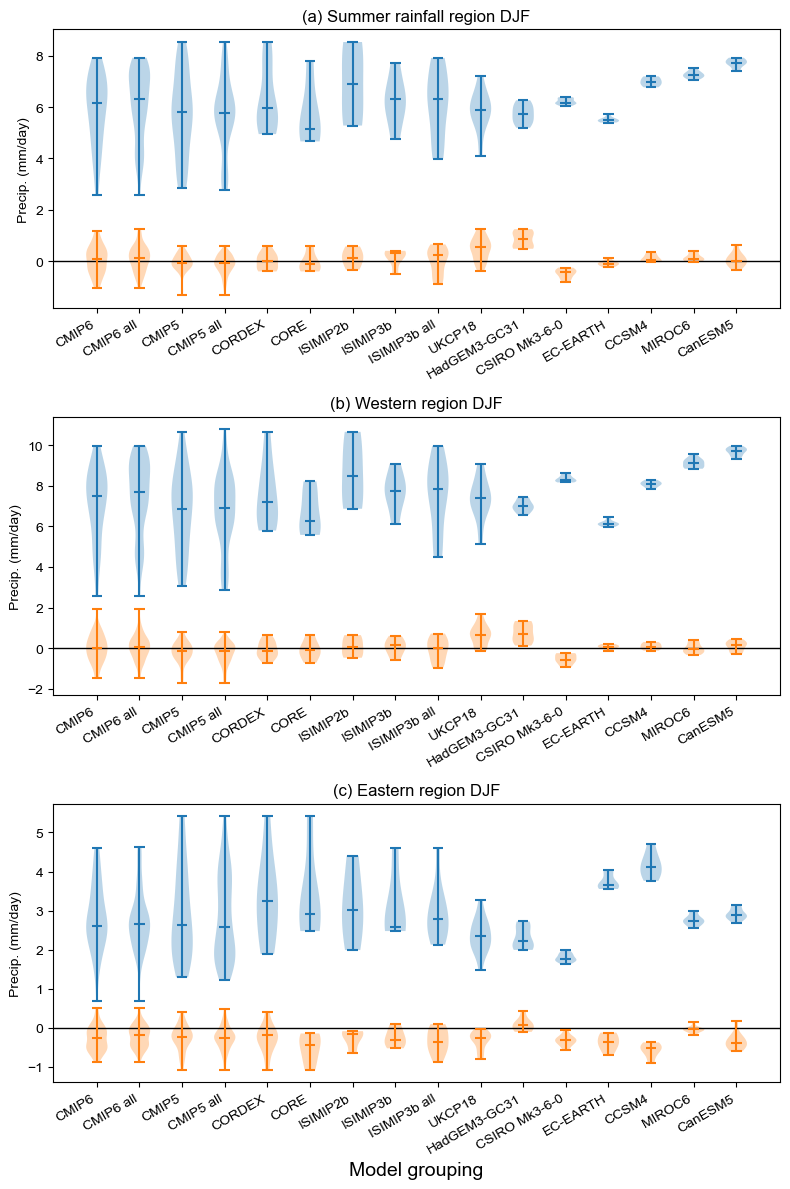

In [14]:
## Create Figure 4
# Violin plots for all 4 regions, all for DJF

import matplotlib.patches as mpatches

# Define all regions
#                   Large    Uncertain  West      East      Small
reglat = np.array([[-32,-13],[-22,-13],[-35,-18],[-34,-22],[-22,-13]])
reglon = np.array([[20,41],[20,41],[12,24],[26,35],[21,30]])

# Create figure with subplots
# fig, axs = plt.subplots(2, 2, figsize=(16,10))
fig, axs = plt.subplots(3, 1, figsize=(8,12))
plotx = np.array([0,0,1,1])
ploty = np.array([0,1,0,1])

## This correctly pulls out the ids for a defined region
# Select which region to use, or this could be a loop
# for i in range(0,4):
for i in range(0,3):
    regno = i;
    
    subset_lon_ids = np.arange(0,subsetlo.shape[0],1)
    which_id = subsetlo[:] == reglon[regno,0]+0.5
    lon_id1 = subset_lon_ids[which_id].item()
    which_id = subsetlo[:] == reglon[regno,1]+0.5
    lon_id2 = subset_lon_ids[which_id].item()
    
    subset_lat_ids = np.arange(0,subsetla.shape[0],1)
    which_id = subsetla[:] == reglat[regno,0]+0.5
    lat_id1 = subset_lat_ids[which_id].item()
    which_id = subsetla[:] == reglat[regno,1]+0.5
    lat_id2 = subset_lat_ids[which_id].item()
    
    # Show the lat-long of the grid cell centres that are selected
    # The edges of these grid cells should match the box defined above
    subsetlo[lon_id1:lon_id2]
    subsetla[lat_id1:lat_id2]
    
    # Make the same plot for land points/SADC countries only -> This makes ocean points NaN
    ## Create a 4D array of same dimension sizes as the climate data
    areas2d = np.array(LSM_area[lat_id1:lat_id2,lon_id1:lon_id2])
    # For all CMIP
    areas3d_a = np.repeat(areas2d[:, :, np.newaxis], 186, axis=2)
    areas4d_a = np.repeat(areas3d_a[:, :, :, np.newaxis], 2, axis=3)
    # Convert to a fractional area
    areas4d_frac_a = areas4d_a / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)
    
    areas3d_b = np.repeat(areas2d[:, :, np.newaxis], 83, axis=2)
    areas4d_b = np.repeat(areas3d_b[:, :, :, np.newaxis], 2, axis=3)
    # Convert to a fractional area
    areas4d_frac_b = areas4d_b / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)
    
    areas3d_c = np.repeat(areas2d[:, :, np.newaxis], 15, axis=2)
    areas4d_c = np.repeat(areas3d_c[:, :, :, np.newaxis], 2, axis=3)
    # Convert to a fractional area
    areas4d_frac_c = areas4d_c / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)
    
    y_all = np.nansum(np.nansum(np.mean(P[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
    y_rip = np.nansum(np.nansum(np.mean(P2[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
    y_UKCP18 = np.nansum(np.nansum(P_UKCP18_2[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    
    ## Plot combined figure of map of regions and violins for each region
    
    # Setup figure with sub-plots
    
    
    labels = []
    def add_label(violin, label):
        color = violin["bodies"][0].get_facecolor().flatten()
        labels.append((mpatches.Patch(color=color), label))
        
    ys = y_all
    data_baseline = [y_rip[0:44,0],ys[ids6,0],y_rip[44:94,0],ys[ids5,0],
                     ys[idsCORDEX,0],ys[idsCORE,0],ys[idsISIMIP2b,0],ys[idsISIMIP3b,0],ys[idsISIMIP3ball,0],y_UKCP18[:,0],ys[idsHadGEM,0],
                     ys[idsCSIRO,0],ys[idsECE,0],ys[idsCCSM,0],ys[idsMIROC,0],ys[idsCanESM,0],]
    data_change = [y_rip[0:44,1],ys[ids6,1],y_rip[44:94,1],ys[ids5,1],
                   ys[idsCORDEX,1],ys[idsCORE,1],ys[idsISIMIP2b,1],ys[idsISIMIP3b,1],ys[idsISIMIP3ball,1],y_UKCP18[:,1],ys[idsHadGEM,1],
                   ys[idsCSIRO,1],ys[idsECE,1],ys[idsCCSM,1],ys[idsMIROC,1],ys[idsCanESM,1],]
    labels = []
    
    # axs[plotx[i],ploty[i]].axhline(y=0, color='k', linestyle='-', linewidth=1)
    # add_label(axs[plotx[i],ploty[i]].violinplot(data_baseline,showmeans=False,showextrema=True,showmedians=True), "1985-2014")   
    # add_label(axs[plotx[i],ploty[i]].violinplot(data_change,showmeans=False,showextrema=True,showmedians=True), "Change 2070-2099")   
    # titles=[ '(a) Summer rainfall region DJF', '(b) Northeastern region DJF', '(c) Western region DJF', '(d) Eastern region DJF'] 
    # axs[plotx[i],ploty[i]].set_title(titles[i],fontname = 'arial')
    # axs[plotx[i],ploty[i]].set_ylabel('Precip. (mm/day)')
    # axs[plotx[i],ploty[i]].set_xticks(np.r_[1:17],labels=[ 'CMIP6', 'CMIP6 all', 'CMIP5', 'CMIP5 all','CORDEX','CORE','ISIMIP2b','ISIMIP3b','ISIMIP3b all',
    #                                   'UKCP18','HadGEM3-GC31','CSIRO Mk3-6-0','EC-EARTH','CCSM4','MIROC6','CanESM5'],rotation=30,ha='right')
    # axs[plotx[i],ploty[i]].set_xlabel('Model grouping');
    
    axs[i].axhline(y=0, color='k', linestyle='-', linewidth=1)
    add_label(axs[i].violinplot(data_baseline,showmeans=False,showextrema=True,showmedians=True), "1985-2014")   
    add_label(axs[i].violinplot(data_change,showmeans=False,showextrema=True,showmedians=True), "Change 2070-2099")   
    titles=[ '(a) Summer rainfall region DJF', '(b) Western region DJF', '(c) Eastern region DJF'] 
    axs[i].set_title(titles[i],fontname = 'arial')
    axs[i].set_ylabel('Precip. (mm/day)')
    axs[i].set_xticks(np.r_[1:17],labels=[ 'CMIP6', 'CMIP6 all', 'CMIP5', 'CMIP5 all','CORDEX','CORE','ISIMIP2b','ISIMIP3b','ISIMIP3b all',
                                      'UKCP18','HadGEM3-GC31','CSIRO Mk3-6-0','EC-EARTH','CCSM4','MIROC6','CanESM5'],rotation=30,ha='right')
    
    
axs[2].set_xlabel('Model grouping', fontsize=14);
fig.tight_layout()
plt.savefig('Fig4_Violins_DJF_all.pdf')


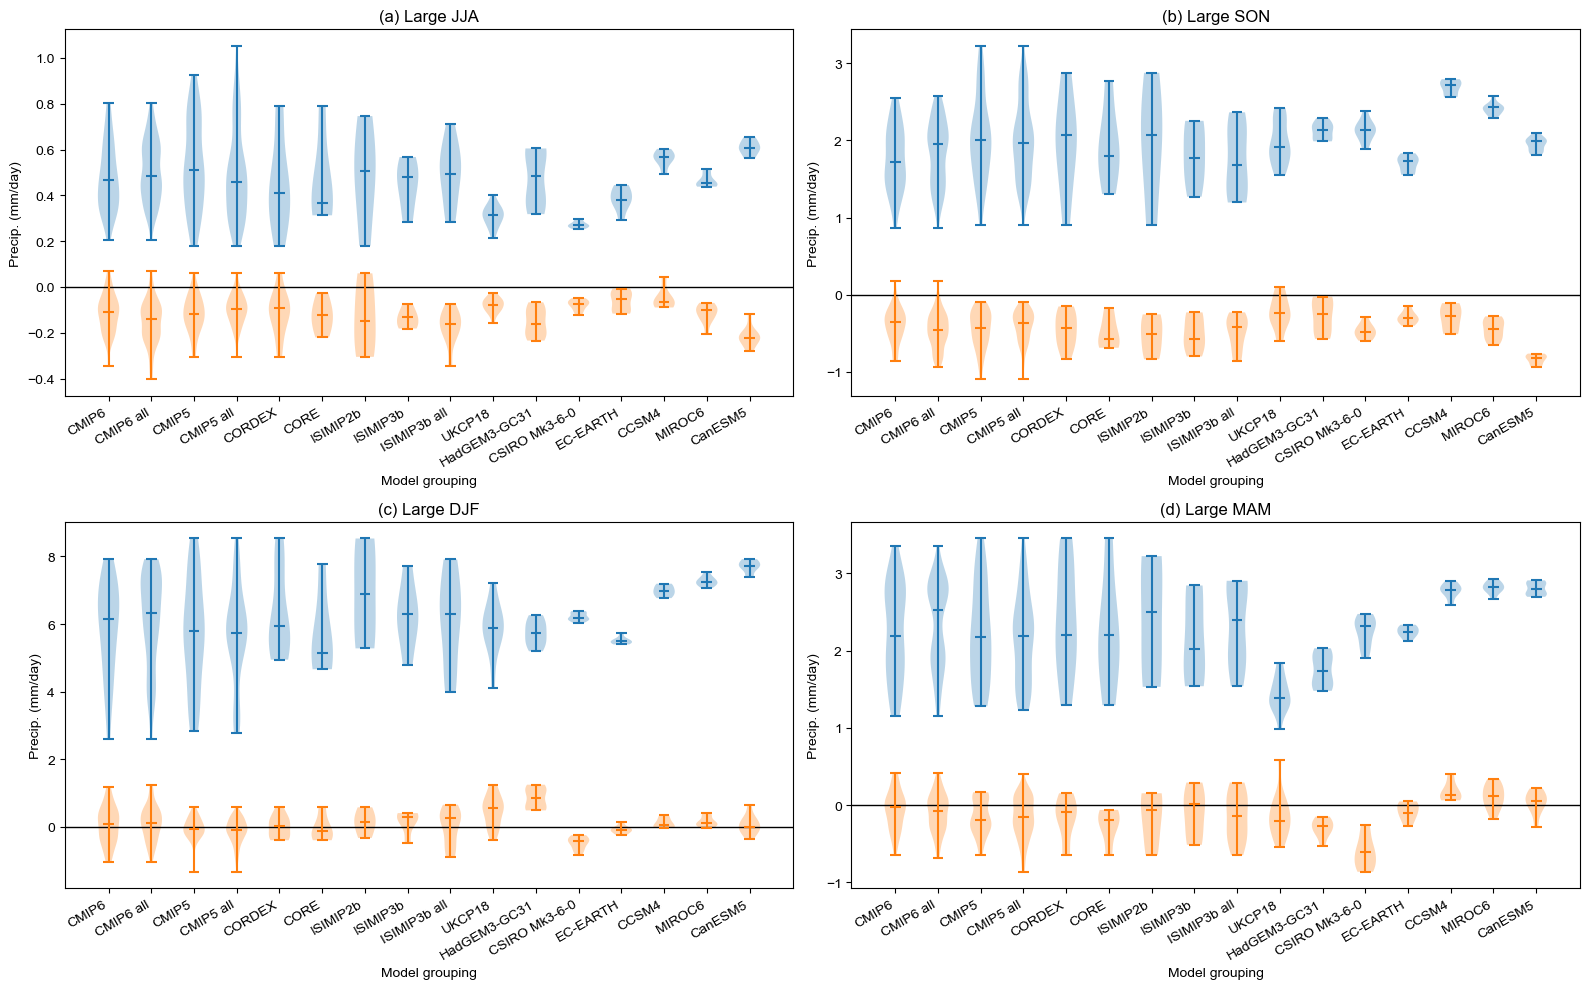

In [33]:
## Create Supplementary Figure 7
# Violin plots for all seasons, only for large region

import matplotlib.patches as mpatches

# Define all regions
#                   Large    Uncertain  West      East      Small
reglat = np.array([[-32,-13],[-22,-13],[-35,-18],[-34,-22],[-22,-13]])
reglon = np.array([[20,41],[20,41],[12,24],[26,35],[21,30]])

# Create figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(16,10))
plotx = np.array([0,0,1,1])
ploty = np.array([0,1,0,1])


# Create area mask for large region
regno = 0

subset_lon_ids = np.arange(0,subsetlo.shape[0],1)
which_id = subsetlo[:] == reglon[regno,0]+0.5
lon_id1 = subset_lon_ids[which_id].item()
which_id = subsetlo[:] == reglon[regno,1]+0.5
lon_id2 = subset_lon_ids[which_id].item()

subset_lat_ids = np.arange(0,subsetla.shape[0],1)
which_id = subsetla[:] == reglat[regno,0]+0.5
lat_id1 = subset_lat_ids[which_id].item()
which_id = subsetla[:] == reglat[regno,1]+0.5
lat_id2 = subset_lat_ids[which_id].item()

# Show the lat-long of the grid cell centres that are selected
# The edges of these grid cells should match the box defined above
subsetlo[lon_id1:lon_id2]
subsetla[lat_id1:lat_id2]

# Make the same plot for land points/SADC countries only -> This makes ocean points NaN
## Create a 4D array of same dimension sizes as the climate data
areas2d = np.array(LSM_area[lat_id1:lat_id2,lon_id1:lon_id2])
# For all CMIP
areas3d_a = np.repeat(areas2d[:, :, np.newaxis], 186, axis=2)
areas4d_a = np.repeat(areas3d_a[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_a = areas4d_a / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_b = np.repeat(areas2d[:, :, np.newaxis], 83, axis=2)
areas4d_b = np.repeat(areas3d_b[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_b = areas4d_b / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_c = np.repeat(areas2d[:, :, np.newaxis], 15, axis=2)
areas4d_c = np.repeat(areas3d_c[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_c = areas4d_c / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)


## Plot each season. Loop could be improved but copy-paste is okay for now.
for i in range(0,4):
    if i == 0:
        y_all = np.nansum(np.nansum(np.mean(P[[5,6,7],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[5,6,7],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_2b[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 1:
        y_all = np.nansum(np.nansum(np.mean(P[[8,9,10],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[8,9,10],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_2c[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 2:
        y_all = np.nansum(np.nansum(np.mean(P[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[0,1,11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_2[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 3:
        y_all = np.nansum(np.nansum(np.mean(P[[2,3,4],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[2,3,4],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_2a[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    
    
    ## Plot combined figure of map of regions and violins for each region    
    labels = []
    def add_label(violin, label):
        color = violin["bodies"][0].get_facecolor().flatten()
        labels.append((mpatches.Patch(color=color), label))
        
    ys = y_all
    data_baseline = [y_rip[0:44,0],ys[ids6,0],y_rip[44:94,0],ys[ids5,0],
                     ys[idsCORDEX,0],ys[idsCORE,0],ys[idsISIMIP2b,0],ys[idsISIMIP3b,0],ys[idsISIMIP3ball,0],y_UKCP18[:,0],ys[idsHadGEM,0],
                     ys[idsCSIRO,0],ys[idsECE,0],ys[idsCCSM,0],ys[idsMIROC,0],ys[idsCanESM,0],]
    data_change = [y_rip[0:44,1],ys[ids6,1],y_rip[44:94,1],ys[ids5,1],
                   ys[idsCORDEX,1],ys[idsCORE,1],ys[idsISIMIP2b,1],ys[idsISIMIP3b,1],ys[idsISIMIP3ball,1],y_UKCP18[:,1],ys[idsHadGEM,1],
                   ys[idsCSIRO,1],ys[idsECE,1],ys[idsCCSM,1],ys[idsMIROC,1],ys[idsCanESM,1],]
    labels = []
    
    axs[plotx[i],ploty[i]].axhline(y=0, color='k', linestyle='-', linewidth=1)
    add_label(axs[plotx[i],ploty[i]].violinplot(data_baseline,showmeans=False,showextrema=True,showmedians=True), "1985-2014")   
    add_label(axs[plotx[i],ploty[i]].violinplot(data_change,showmeans=False,showextrema=True,showmedians=True), "Change 2070-2099")   
    titles=[ '(a) Large JJA', '(b) Large SON', '(c) Large DJF', '(d) Large MAM'] 
    axs[plotx[i],ploty[i]].set_title(titles[i],fontname = 'arial')
    axs[plotx[i],ploty[i]].set_ylabel('Precip. (mm/day)')
    axs[plotx[i],ploty[i]].set_xticks(np.r_[1:17],labels=[ 'CMIP6', 'CMIP6 all', 'CMIP5', 'CMIP5 all','CORDEX','CORE','ISIMIP2b','ISIMIP3b','ISIMIP3b all',
                                      'UKCP18','HadGEM3-GC31','CSIRO Mk3-6-0','EC-EARTH','CCSM4','MIROC6','CanESM5'],rotation=30,ha='right')
    axs[plotx[i],ploty[i]].set_xlabel('Model grouping');
    

fig.tight_layout()
plt.savefig('SuppFig8_Violins_seasons_large.pdf')


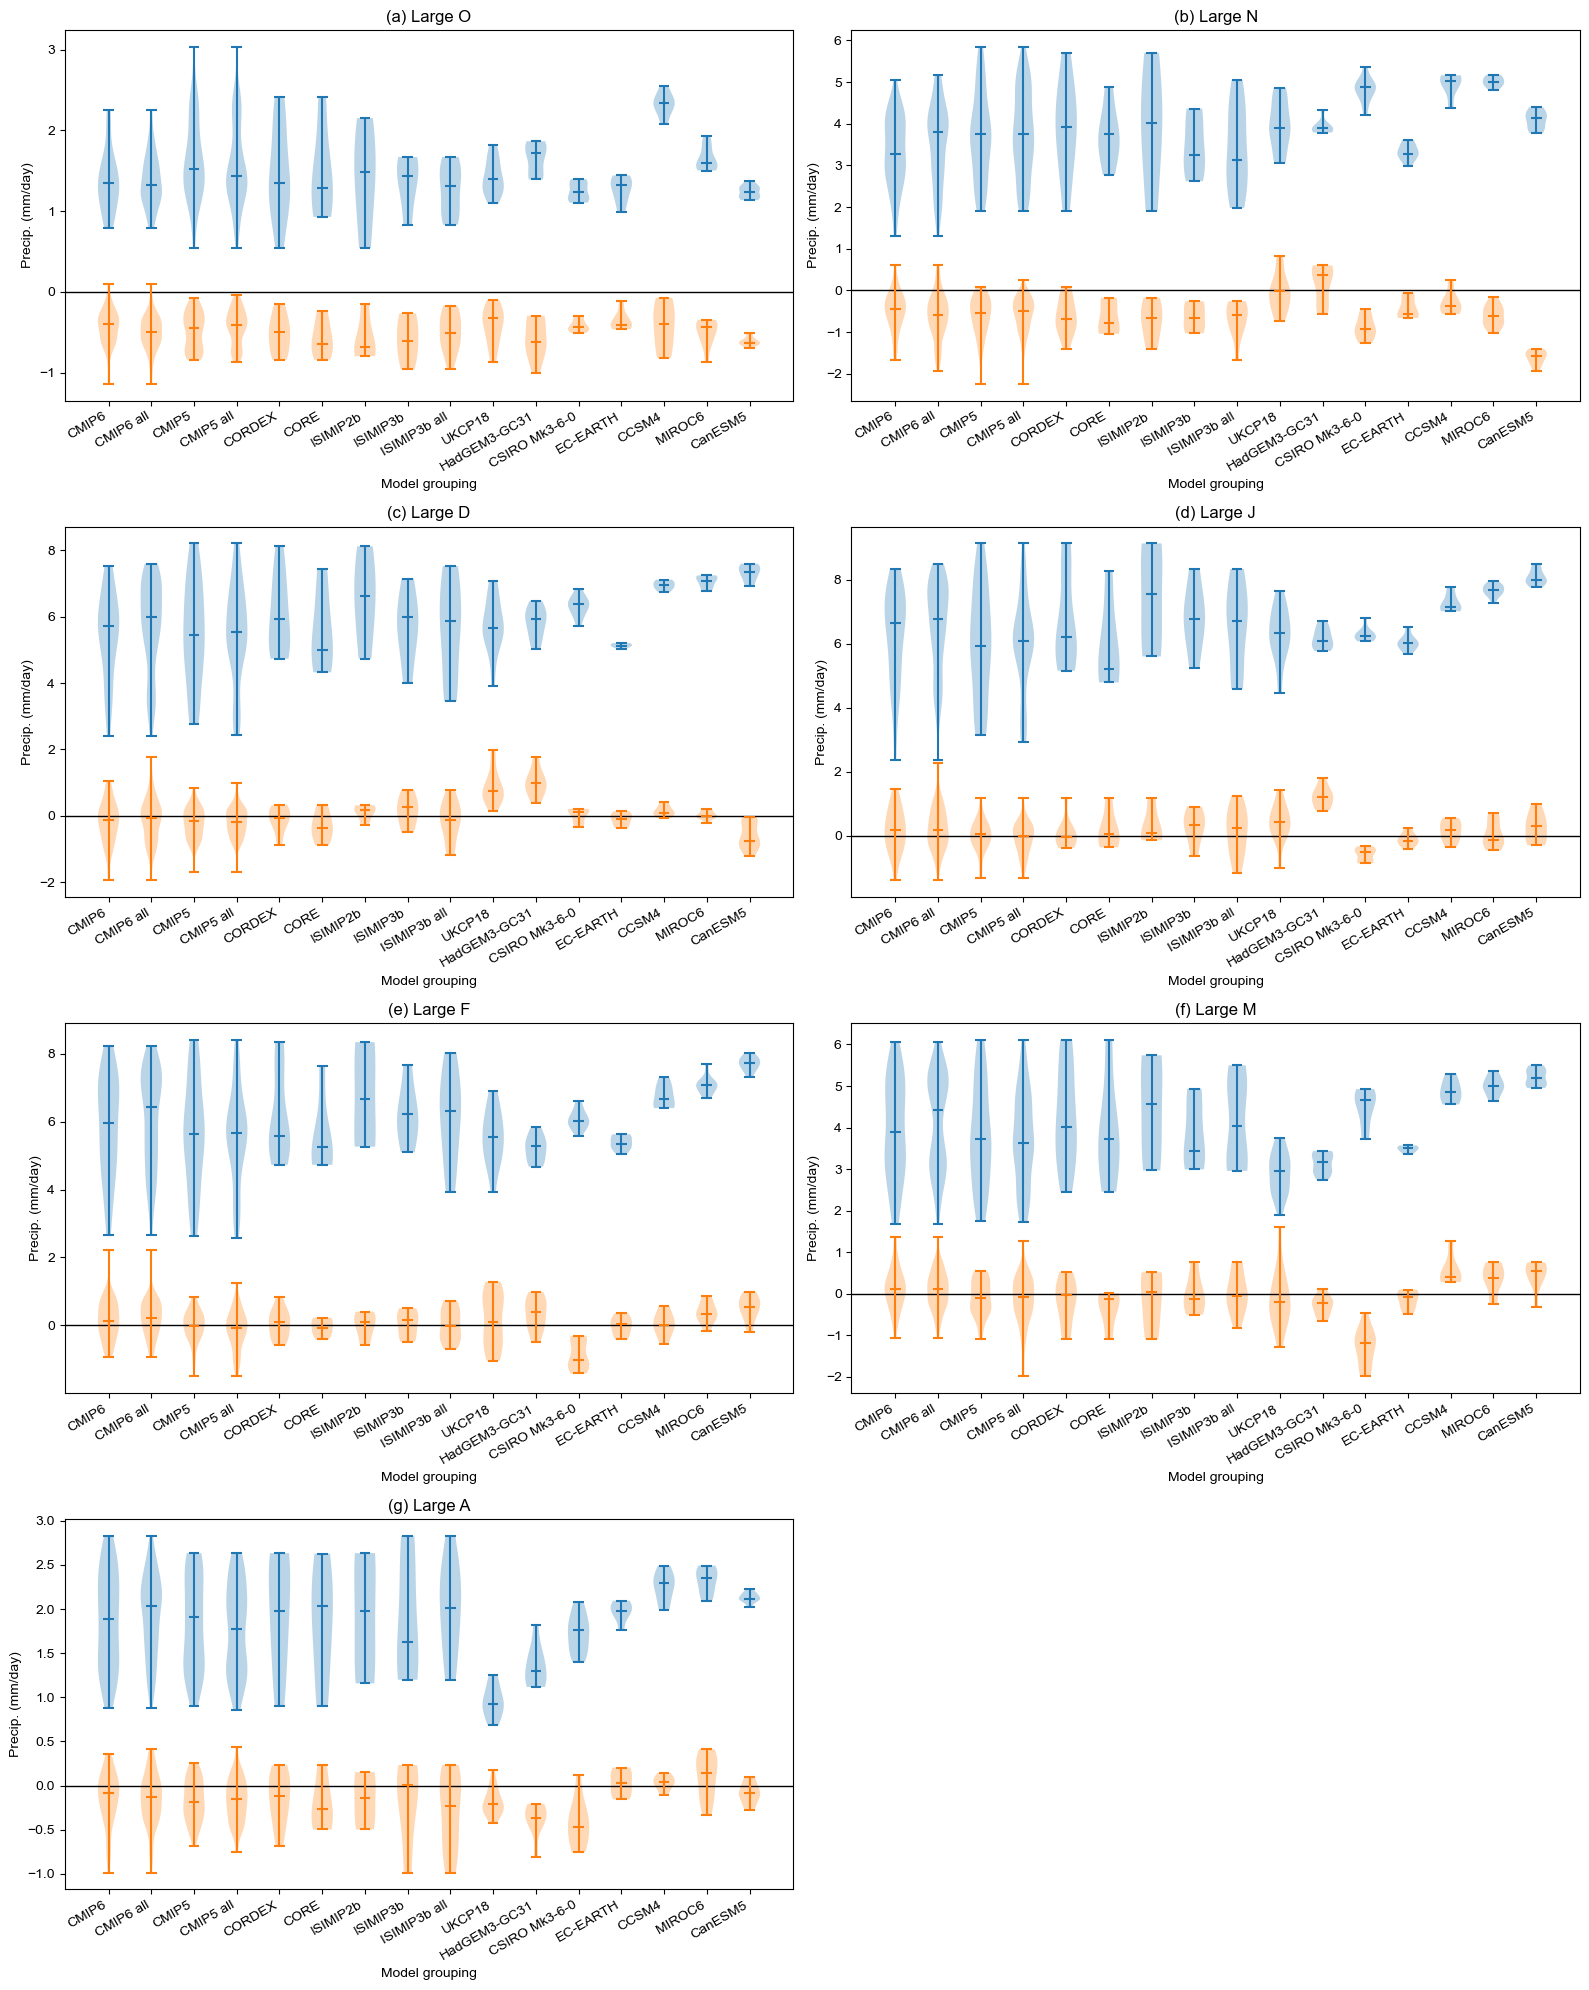

In [12]:
## Create Supplementary Figure X
# Violin plots for several months, only for large region

import matplotlib.patches as mpatches

# Define all regions
#                   Large    Uncertain  West      East      Small
reglat = np.array([[-32,-13],[-22,-13],[-35,-18],[-34,-22],[-22,-13]])
reglon = np.array([[20,41],[20,41],[12,24],[26,35],[21,30]])

# Create figure with subplots
fig, axs = plt.subplots(4, 2, figsize=(16,20))
plotx = np.array([0,0,1,1,2,2,3,3])
ploty = np.array([0,1,0,1,0,1,0,1])


# Create area mask for large region
regno = 0

subset_lon_ids = np.arange(0,subsetlo.shape[0],1)
which_id = subsetlo[:] == reglon[regno,0]+0.5
lon_id1 = subset_lon_ids[which_id].item()
which_id = subsetlo[:] == reglon[regno,1]+0.5
lon_id2 = subset_lon_ids[which_id].item()

subset_lat_ids = np.arange(0,subsetla.shape[0],1)
which_id = subsetla[:] == reglat[regno,0]+0.5
lat_id1 = subset_lat_ids[which_id].item()
which_id = subsetla[:] == reglat[regno,1]+0.5
lat_id2 = subset_lat_ids[which_id].item()

# Show the lat-long of the grid cell centres that are selected
# The edges of these grid cells should match the box defined above
subsetlo[lon_id1:lon_id2]
subsetla[lat_id1:lat_id2]

# Make the same plot for land points/SADC countries only -> This makes ocean points NaN
## Create a 4D array of same dimension sizes as the climate data
areas2d = np.array(LSM_area[lat_id1:lat_id2,lon_id1:lon_id2])
# For all CMIP
areas3d_a = np.repeat(areas2d[:, :, np.newaxis], 186, axis=2)
areas4d_a = np.repeat(areas3d_a[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_a = areas4d_a / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_b = np.repeat(areas2d[:, :, np.newaxis], 83, axis=2)
areas4d_b = np.repeat(areas3d_b[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_b = areas4d_b / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)

areas3d_c = np.repeat(areas2d[:, :, np.newaxis], 15, axis=2)
areas4d_c = np.repeat(areas3d_c[:, :, :, np.newaxis], 2, axis=3)
# Convert to a fractional area
areas4d_frac_c = areas4d_c / np.nansum(np.nansum(areas2d,axis = 1),axis = 0)


## Plot each season. Loop could be improved but copy-paste is okay for now.
for i in range(0,7):
    if i == 0:
        y_all = np.nansum(np.nansum(np.mean(P[[9],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[9],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_O[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 1:
        y_all = np.nansum(np.nansum(np.mean(P[[10],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[10],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_N[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 2:
        y_all = np.nansum(np.nansum(np.mean(P[[11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[11],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_D[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 3:
        y_all = np.nansum(np.nansum(np.mean(P[[0],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[0],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_J[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 4:
        y_all = np.nansum(np.nansum(np.mean(P[[1],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[1],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_F[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 5:
        y_all = np.nansum(np.nansum(np.mean(P[[2],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[2],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_M[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    elif i == 6:
        y_all = np.nansum(np.nansum(np.mean(P[[3],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_a, axis=1), axis=0)
        y_rip = np.nansum(np.nansum(np.mean(P2[[3],lat_id1:lat_id2,lon_id1:lon_id2,:,:], axis=0) * areas4d_frac_b, axis=1), axis=0)
        y_UKCP18 = np.nansum(np.nansum(P_UKCP18_A[lat_id1:lat_id2,lon_id1:lon_id2,:,:] * areas4d_frac_c, axis=1), axis=0)
    
    
    ## Plot combined figure of map of regions and violins for each region    
    labels = []
    def add_label(violin, label):
        color = violin["bodies"][0].get_facecolor().flatten()
        labels.append((mpatches.Patch(color=color), label))
        
    ys = y_all
    data_baseline = [y_rip[0:44,0],ys[ids6,0],y_rip[44:94,0],ys[ids5,0],
                     ys[idsCORDEX,0],ys[idsCORE,0],ys[idsISIMIP2b,0],ys[idsISIMIP3b,0],ys[idsISIMIP3ball,0],y_UKCP18[:,0],ys[idsHadGEM,0],
                     ys[idsCSIRO,0],ys[idsECE,0],ys[idsCCSM,0],ys[idsMIROC,0],ys[idsCanESM,0],]
    data_change = [y_rip[0:44,1],ys[ids6,1],y_rip[44:94,1],ys[ids5,1],
                   ys[idsCORDEX,1],ys[idsCORE,1],ys[idsISIMIP2b,1],ys[idsISIMIP3b,1],ys[idsISIMIP3ball,1],y_UKCP18[:,1],ys[idsHadGEM,1],
                   ys[idsCSIRO,1],ys[idsECE,1],ys[idsCCSM,1],ys[idsMIROC,1],ys[idsCanESM,1],]
    labels = []
    
    axs[plotx[i],ploty[i]].axhline(y=0, color='k', linestyle='-', linewidth=1)
    add_label(axs[plotx[i],ploty[i]].violinplot(data_baseline,showmeans=False,showextrema=True,showmedians=True), "1985-2014")   
    add_label(axs[plotx[i],ploty[i]].violinplot(data_change,showmeans=False,showextrema=True,showmedians=True), "Change 2070-2099")   
    titles=[ '(a) Large O', '(b) Large N', '(c) Large D', '(d) Large J', '(e) Large F', '(f) Large M', '(g) Large A'] 
    axs[plotx[i],ploty[i]].set_title(titles[i],fontname = 'arial')
    axs[plotx[i],ploty[i]].set_ylabel('Precip. (mm/day)')
    axs[plotx[i],ploty[i]].set_xticks(np.r_[1:17],labels=[ 'CMIP6', 'CMIP6 all', 'CMIP5', 'CMIP5 all','CORDEX','CORE','ISIMIP2b','ISIMIP3b','ISIMIP3b all',
                                      'UKCP18','HadGEM3-GC31','CSIRO Mk3-6-0','EC-EARTH','CCSM4','MIROC6','CanESM5'],rotation=30,ha='right')
    axs[plotx[i],ploty[i]].set_xlabel('Model grouping');
    
axs[-1, -1].axis('off')

fig.tight_layout()
plt.savefig('SuppFigX_Violins_months_large.pdf')
